In [2]:
from jmetal.core.problem import FloatProblem
from jmetal.core.solution import FloatSolution

from jmetal.algorithm.multiobjective.nsgaii import NSGAII

from jmetal.operator.crossover import SBXCrossover
from jmetal.operator.mutation import PolynomialMutation
from jmetal.util.termination_criterion import StoppingByEvaluations

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.datasets import load_iris

import time


class KNNMultiObjective(FloatProblem):

    def __init__(self):
        super().__init__()

        self.lower_bound = [1]
        self.upper_bound = [20]

        self.data = load_iris()

    def number_of_variables(self):
        return 1

    def number_of_objectives(self):
        return 2 

    def number_of_constraints(self):
        return 1

    def evaluate(self, solution):
        k = max(1, int(round(solution.variables[0])))

        model = KNeighborsClassifier(n_neighbors=k)

        start = time.time()

        score = cross_val_score(
            model,
            self.data.data,
            self.data.target,
            cv=3
        ).mean()

        end = time.time()

        tiempo = end - start

        # jMetal minimiza TODO
        solution.objectives[0] = -score   # maximizar accuracy
        solution.objectives[1] = tiempo   # minimizar tiempo

        #Restriccion
        solution.constraints[0] = score - 0.99

        return solution

    def create_solution(self):
        return FloatSolution(
            self.lower_bound,
            self.upper_bound,
            self.number_of_objectives(),
            self.number_of_constraints()   #definir numero de restricciones
        )

    def name(self):
        return "KNN Multiobjetivo (accuracy vs tiempo)"

In [3]:
problem = KNNMultiObjective()

algorithm = NSGAII(
    problem=problem,
    population_size=20,
    offspring_population_size=20,
    mutation=PolynomialMutation(probability=0.2, distribution_index=20),
    crossover=SBXCrossover(probability=0.9, distribution_index=20),
    termination_criterion=StoppingByEvaluations(max_evaluations=100)
)

algorithm.run()

result = algorithm.result()

[2026-05-03 23:54:41,802] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-05-03 23:54:41,803] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-05-03 23:54:41,986] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-05-03 23:54:41,987] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-05-03 23:54:42,614] [jmetal.core.algorithm] [DEBUG] Finished!


In [4]:
for solution in result:
    k = int(round(solution.variables[0]))
    accuracy = -solution.objectives[0]
    tiempo = solution.objectives[1]

    print(f"k={k} | accuracy={accuracy:.4f} | tiempo={tiempo:.4f}")

k=0 | accuracy=0.9600 | tiempo=0.0060
k=3 | accuracy=0.9733 | tiempo=0.0082
k=1 | accuracy=0.9600 | tiempo=0.0060
k=0 | accuracy=0.9600 | tiempo=0.0061
k=1 | accuracy=0.9600 | tiempo=0.0061
k=0 | accuracy=0.9600 | tiempo=0.0062
k=1 | accuracy=0.9600 | tiempo=0.0062
k=0 | accuracy=0.9600 | tiempo=0.0062
k=2 | accuracy=0.9467 | tiempo=0.0062
k=0 | accuracy=0.9600 | tiempo=0.0062
k=0 | accuracy=0.9600 | tiempo=0.0063
k=1 | accuracy=0.9600 | tiempo=0.0063
k=0 | accuracy=0.9600 | tiempo=0.0063
k=0 | accuracy=0.9600 | tiempo=0.0063
k=1 | accuracy=0.9600 | tiempo=0.0063
k=1 | accuracy=0.9600 | tiempo=0.0064
k=1 | accuracy=0.9600 | tiempo=0.0064
k=0 | accuracy=0.9600 | tiempo=0.0064
k=0 | accuracy=0.9600 | tiempo=0.0065
k=0 | accuracy=0.9600 | tiempo=0.0065


In [5]:
for s in result:
    print("k:", int(s.variables[0]),
          "accuracy:", -s.objectives[0],
          "tiempo:", s.objectives[1],
          "constraint:", s.constraints[0])

k: 0 accuracy: 0.96 tiempo: 0.006043672561645508 constraint: -0.030000000000000027
k: 2 accuracy: 0.9733333333333333 tiempo: 0.00820612907409668 constraint: -0.01666666666666672
k: 1 accuracy: 0.96 tiempo: 0.006044626235961914 constraint: -0.030000000000000027
k: 0 accuracy: 0.96 tiempo: 0.00608515739440918 constraint: -0.030000000000000027
k: 1 accuracy: 0.96 tiempo: 0.006102085113525391 constraint: -0.030000000000000027
k: 0 accuracy: 0.96 tiempo: 0.006155729293823242 constraint: -0.030000000000000027
k: 1 accuracy: 0.96 tiempo: 0.0061872005462646484 constraint: -0.030000000000000027
k: 0 accuracy: 0.96 tiempo: 0.006217002868652344 constraint: -0.030000000000000027
k: 1 accuracy: 0.9466666666666667 tiempo: 0.006199359893798828 constraint: -0.043333333333333335
k: 0 accuracy: 0.96 tiempo: 0.006239175796508789 constraint: -0.030000000000000027
k: 0 accuracy: 0.96 tiempo: 0.006271839141845703 constraint: -0.030000000000000027
k: 1 accuracy: 0.96 tiempo: 0.0063114166259765625 constraint:

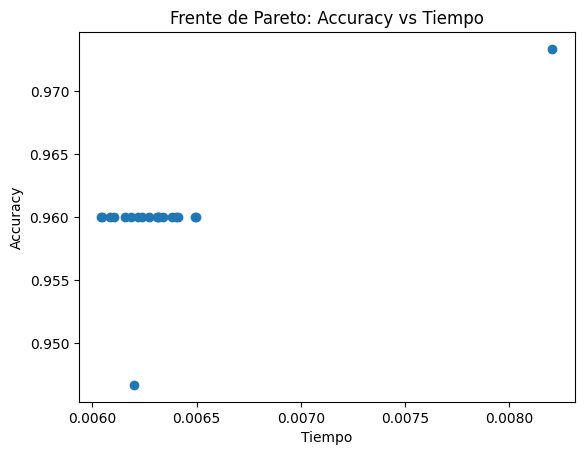

In [6]:
import matplotlib.pyplot as plt

accuracies = [-s.objectives[0] for s in result]
times = [s.objectives[1] for s in result]

plt.scatter(times, accuracies)
plt.xlabel("Tiempo")
plt.ylabel("Accuracy")
plt.title("Frente de Pareto: Accuracy vs Tiempo")
#plt.ylim(0.95, 0.97)
plt.show()